# Описание, предобработка и анализ данных

Этот ноутбук посвящен анализу данных для задачи сегментации глиом — ключевого этапа разработки системы поддержки принятия врачебных решений при контурировании опухолей радиационными онкологами.


## 1. Источник и состав данных

Для работы используются открытые наборы данных:

1) **Medical Segmentation Decathlon (MSD) - Brain Tumour (Task01):**
- 484 случая.
- Формат 4D NIfTI (4 модальности в одном файле).
- Ориентация RAS.

2) **UPENN-GBM:**
- 147 случаев.
- Формат 3D NIfTI (каждая модальность — отдельный файл).
- Ориентация LPS.

В обоих датасетах представлены модальности: **T1, T1ce, T2, FLAIR**.

Цель — сегментация трех областей: **TC (Tumor Core, ядро)**, **ET (Enhancing Tumor, активная часть)**, **WT (Whole Tumor, вся опухоль**, т.е TC + ET + перитуморальный отёк).

Labels (метки):
*   **0**: Фон (здоровая ткань).
*   **1**: Перитуморальный отёк (ED).
*   **2**: Некроз и неконтрастное ядро (NCR/NET).
*   **3**: Активная часть опухоли (ET).

Соотношение меток с клиническими компонентами:
1. WT (Whole Tumor) = Label 1 + Label 2 + Label 3 (вся область поражения, включая отёк).
2. TC (Tumor Core) = Label 2 + Label 3 (все ядро целиком).
3. ET (Enhancing Tumor) = только Label 3.

## 2. Предобработка данных

Для приведения данных к единому формату были выполнены следующие преобразования датасете UPENN-GBM (`scripts/prepare_upenn_4d.py`):
- маппинг модальностей в соответствие с MDS;
- cтэкинг 3D-модальностей в один 4D NIfTI файл;
- переориентация из LPS к стандарту RAS;
- метки UPENN {1, 2, 4} перекодированы в стандарт BraTS/MSD {1, 2, 3}.

Для обеспечения надежности данных на всех этапах подготовки проводились следующие проверки:

1.  Проверка целостности: Скрипт `scripts/check_broken_files.py` подтверждает, что все файлы в raw-директориях читаются без ошибок.
2.  Валидация соответствия: Скрипты `scripts/check_msd_match.py` и `scripts/check_upenn_match.py` проверяют наличие пар "снимок-маска" для каждого пациента и их геометрическое соответствие.
3.  Поиск дубликатов: С помощью `scripts/check_duplicates.py` проверено отсутствие дублирующих записей (через MD5-хеширование модальности FLAIR) внутри и между датасетами.
4.  Финальная верификация: Скрипт `scripts/verify_processed.py` проверяет уже обработанные (processed) данные на соответствие RAS-ориентации, совпадение аффинных матриц и корректность маппинга меток {0, 1, 2, 3}.
5.  Сбор метаданных: Скрипт `scripts/collect_metadata.py` агрегирует геометрические параметры (размеры, спейсинг) и хеши всех случаев в единый файл `data/processed/metadata.csv` для последующего статистического анализа.

Размер предобработанных данных:
- MSD_BrainTumour: ~4.4 Гб
- UPENN-GBM: ~1.4 Гб

## 3. Базовый EDA

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nibabel as nib

# Загрузка метаданных
# Если вы запускаете ноутбук из папки notebooks/, используйте '../'
metadata_path = '../data/processed/metadata.csv'
if not os.path.exists(metadata_path):
    # Если запуск из корня проекта
    metadata_path = 'data/processed/metadata.csv'

df = pd.read_csv(metadata_path)
print(f"Загружено {len(df)} случаев из {df['dataset'].unique()}")

Загружено 631 случаев из <StringArray>
['MSD_BrainTumour', 'UPENN-GBM']
Length: 2, dtype: str


### 3.1. Анализ геометрических параметров
Важно проверить, имеют ли снимки одинаковое разрешение и размеры вокселей. Различия в спейсинге могут потребовать ресемплирования.

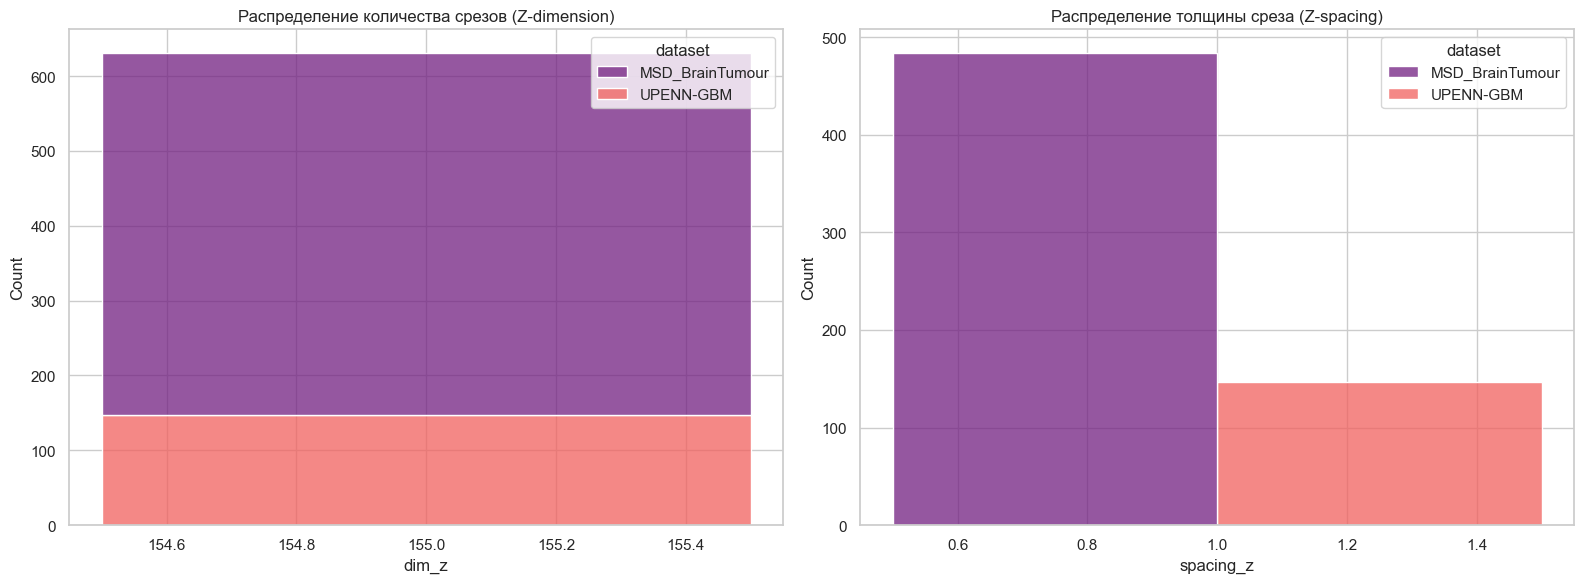

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Размеры по Z (глубина снимка)
sns.histplot(data=df, x='dim_z', hue='dataset', multiple='stack', ax=axes[0], palette='magma')
axes[0].set_title('Распределение количества срезов (Z-dimension)')

# Спейсинг по Z
sns.histplot(data=df, x='spacing_z', hue='dataset', multiple='dodge', ax=axes[1], palette='magma')
axes[1].set_title('Распределение толщины среза (Z-spacing)')

plt.tight_layout()
plt.show()

Выводы.

В данном случае гистограммы представляют собой одиночные пики, что подтверждает, что все 631 случай (как из MSD, так и из UPENN-GBM) имеют абсолютно идентичные геометрические характеристики:
- Размеры (Dimensions): $240 \times 240 \times 155$ вокселей.
- Спейсинг (Spacing): $1.0 \times 1.0 \times 1.0$ мм (изотропное разрешение).

Однако для будущих клинических данных (вне этих датасетов) в пайплайн нужно будет добавить блок автоматического приведения к этому стандарту (240x240x155, 1.0mm) => Ресемплирование.

### 3.2. Анализ распределения интенсивностей
МРТ снимки могут иметь разные диапазоны интенсивностей в зависимости от сканера и настроек. Посмотрим на распределение интенсивностей (без фона) для типичных случаев из обоих датасетов.

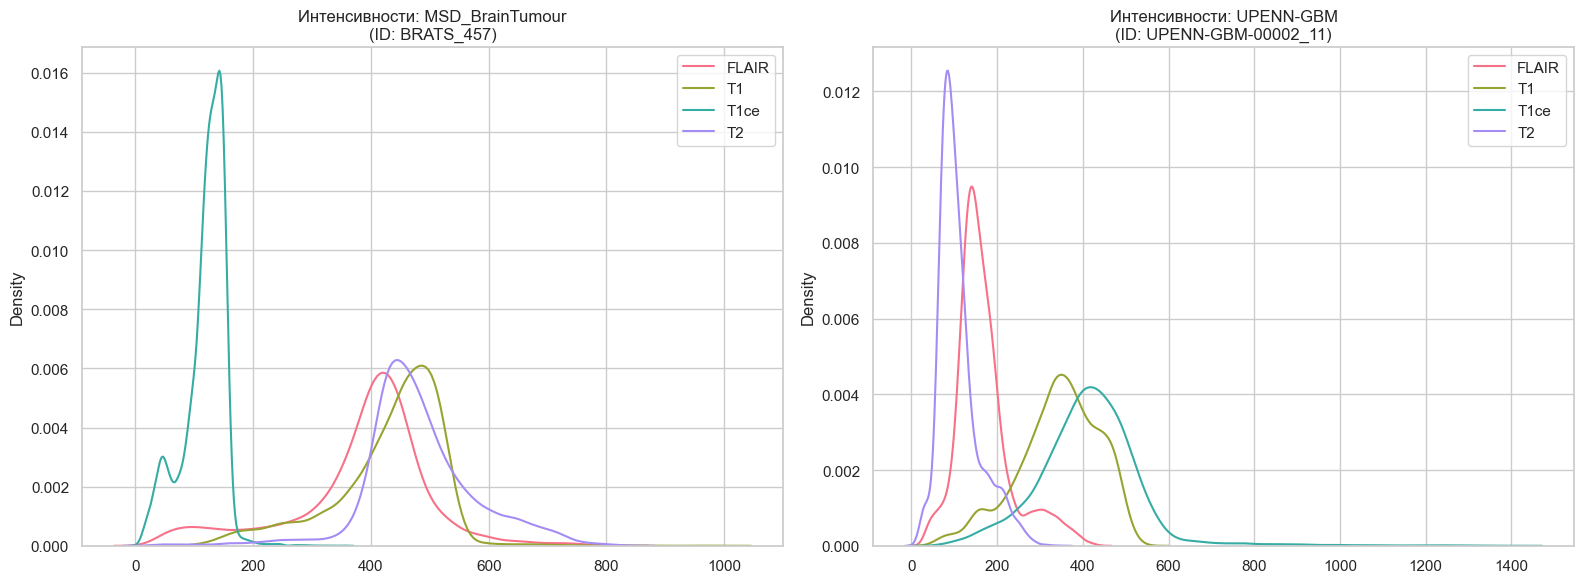

In [35]:
def plot_intensities(df_subset, ax):
    case = df_subset.iloc[0]
    ds = case['dataset']
    pid = case['patient_id']
    
    # Путь к файлу (учитываем возможный запуск из разных папок)
    path = f"../data/processed/{ds}/imagesTr/{pid}.nii.gz"
    if not os.path.exists(path):
        path = f"data/processed/{ds}/imagesTr/{pid}.nii.gz"
        
    img = nib.load(path).get_fdata()
    modalities = ['FLAIR', 'T1', 'T1ce', 'T2']
    colors = sns.color_palette("husl", 4)
    
    for i in range(4):
        data = img[..., i].flatten()
        data = data[data > 0] # Убираем фон (0)
        # Берем подвыборку для ускорения отрисовки KDE
        if len(data) > 10000:
            data = np.random.choice(data, 10000, replace=False)
        sns.kdeplot(data, ax=ax, label=modalities[i], color=colors[i])
    
    ax.set_title(f'Интенсивности: {ds}\n(ID: {pid})')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_intensities(df[df['dataset'] == 'MSD_BrainTumour'], axes[0])
plot_intensities(df[df['dataset'] == 'UPENN-GBM'], axes[1])
plt.tight_layout()
plt.show()

Выводы.
- Общая форма распределений для MSD и UPENN выглядит сопоставимой.
- Значения могут варьироваться от 0 до нескольких тысяч => в пайплайне обязательна нормализация.

### 3.3. Анализ дисбаланса классов
Рассчитаем объемы опухоли и ее компонентов. Это поможет оценить дисбаланс между здоровой тканью и патологией.

In [36]:
# Рассчитаем физические объемы (в мм^3)
df['voxel_volume'] = df['spacing_x'] * df['spacing_y'] * df['spacing_z']
for i in range(1, 4):
    df[f'label_{i}_volume_mm3'] = df[f'label_{i}_voxels'] * df['voxel_volume']
df['total_tumor_volume_mm3'] = df['total_tumor_voxels'] * df['voxel_volume']

# Доля опухоли от всего объема снимка
df['tumor_fraction_%'] = (df['total_tumor_voxels'] / (df['dim_x'] * df['dim_y'] * df['dim_z'])) * 100

print(f"Средняя доля опухоли в объеме снимка: {df['tumor_fraction_%'].mean():.2f}%")
df[['dataset', 'patient_id', 'total_tumor_volume_mm3', 'tumor_fraction_%']].head()

Средняя доля опухоли в объеме снимка: 1.09%


,dataset,patient_id,total_tumor_volume_mm3,tumor_fraction_%
0,MSD_BrainTumour,BRATS_457,73791.0,0.826512
1,MSD_BrainTumour,BRATS_306,32051.0,0.358994
2,MSD_BrainTumour,BRATS_206,266936.0,2.989875
3,MSD_BrainTumour,BRATS_449,131589.0,1.473891
4,MSD_BrainTumour,BRATS_318,95627.0,1.071091


Выводы.

Исходя из выявленного экстремального дисбаланса (опухоль занимает лишь ~1.5% объёма), для обучения рекомендуется:
- Использовать комбинированную функцию потерь **DiceFocalLoss** (Dice — для стабильности на малых объектах, Focal — для внимания к границам).
- Применять **Foreground Over-sampling** и кроппинг, чтобы минимизировать влияние доминирующего фона и сфокусировать обучение на патологических зонах.

### 3.4. Анализ объемов опухоли
Сравним распределение объемов опухоли в двух датасетах.

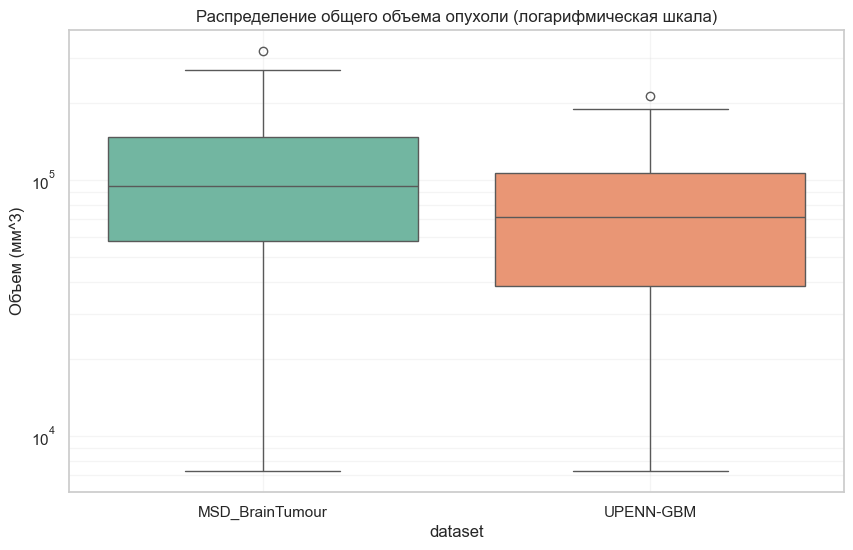

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='dataset', y='total_tumor_volume_mm3', hue='dataset', palette='Set2', legend=False)
plt.yscale('log')
plt.title('Распределение общего объема опухоли (логарифмическая шкала)')
plt.ylabel('Объем (мм^3)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

Выводы.
- Распределения объемов опухолей в датасетах MSD и UPENN-GBM визуально схожи (медианы и межквартильные размахи находятся в одном диапазоне).
- Наличие случаев в нижней части графика (нижние «усы» и выбросы с малым объемом) указывает на наиболее сложные для сегментации примеры.

### 3.5. Дисбаланс компонентов опухоли

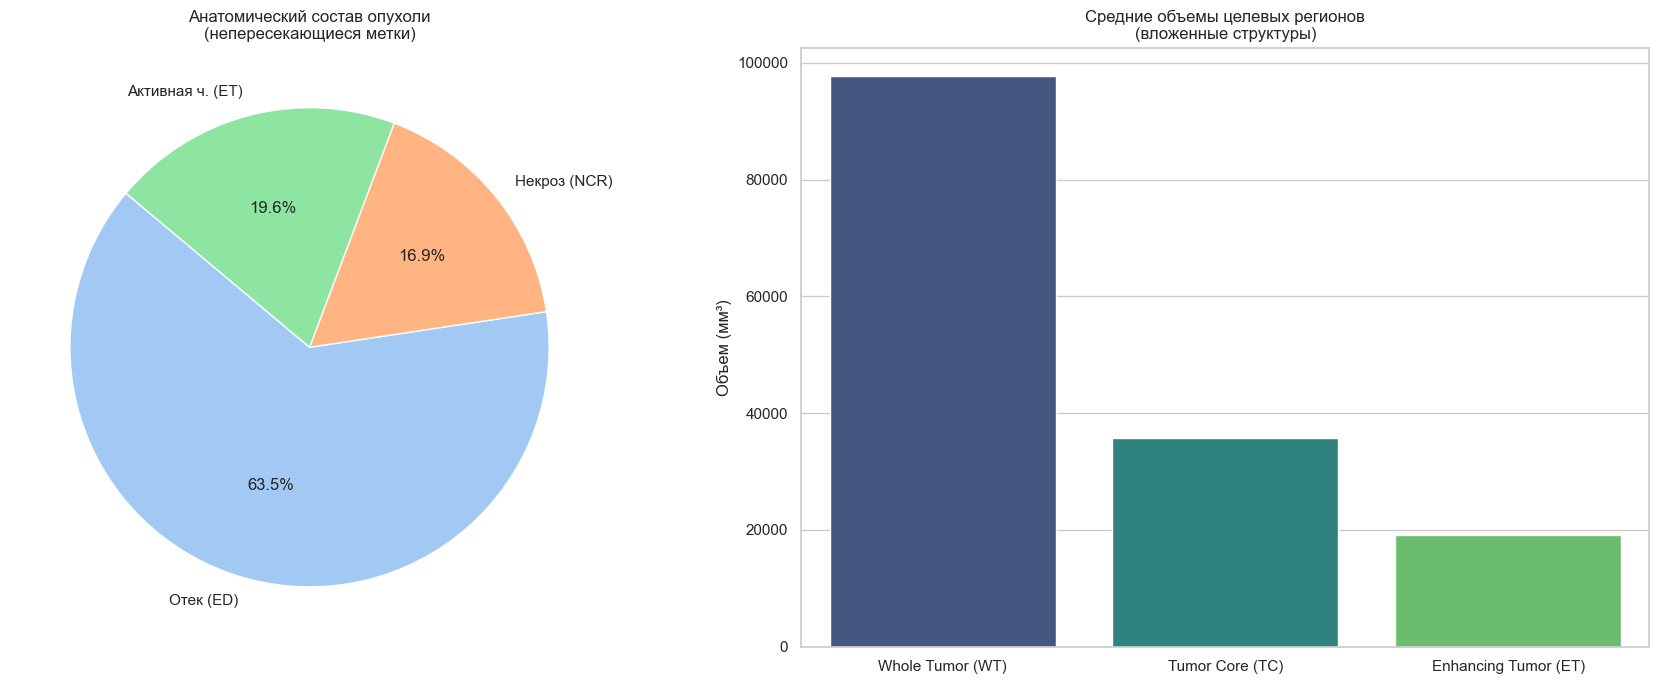

In [38]:
# 1. Расчет объемов клинических регионов (вложенных)
df['WT_vol'] = df['label_1_volume_mm3'] + df['label_2_volume_mm3'] + df['label_3_volume_mm3']
df['TC_vol'] = df['label_2_volume_mm3'] + df['label_3_volume_mm3']
df['ET_vol'] = df['label_3_volume_mm3']

# 2. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Слева: Состав опухоли (Labels) - круговая диаграмма
labels_stats = df[['label_1_volume_mm3', 'label_2_volume_mm3', 'label_3_volume_mm3']].mean()
axes[0].pie(labels_stats, labels=['Отек (ED)', 'Некроз (NCR)', 'Активная ч. (ET)'],
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[0].set_title('Анатомический состав опухоли\n(непересекающиеся метки)')

# Справа: Средние объемы регионов (Regions) - столбчатая диаграмма
region_stats = df[['WT_vol', 'TC_vol', 'ET_vol']].mean()
sns.barplot(x=['Whole Tumor (WT)', 'Tumor Core (TC)', 'Enhancing Tumor (ET)'],
            y=region_stats.values, ax=axes[1], hue=['WT', 'TC', 'ET'], palette='viridis', legend=False)
axes[1].set_title('Средние объемы целевых регионов\n(вложенные структуры)')
axes[1].set_ylabel('Объем (мм³)')

plt.tight_layout()
plt.show()

Выводы.

Самый клинически важный компонент — активная, накапливающая контраст опухоль (ET) — является одним из самых малых по объему => использование комбинированных лосс-функций (Dice + Focal), чтобы модель уделяла достаточно внимания малым, но критически важным структурам.

## 4. Оценка качества разметки и визуальный контроль
### 4.1. Анализ аномалий и топологическая проверка

Для обеспечения высокого качества обучения проведена проверка разметки на наличие технических ошибок и соблюдение биологической иерархии регионов.

In [39]:
# 1. Поиск кейсов с отсутствующими компонентами
missing_et = df[df['label_3_voxels'] == 0]
missing_ncr = df[df['label_2_voxels'] == 0]
print(f"Кейсов без активной части (ET): {len(missing_et)}")
print(f"Кейсов без некротического ядра (NCR): {len(missing_ncr)}")

# 2. Поиск экстремально малых компонентов (потенциальный шум)
# Возьмем порог в 50 вокселей (~0.05 см^3)
noisy_et = df[(df['label_3_voxels'] > 0) & (df['label_3_voxels'] < 50)]
print(f"Кейсов с экстремально малым ET (<50 вокселей): {len(noisy_et)}")

# 3. Топологическая проверка
# В системе непересекающихся меток вложенность ET ⊂ TC ⊂ WT гарантирована.
# Проверим, нет ли случаев с ET, но без общего ядра TC (что было бы ошибкой)
topo_errors = df[(df['label_3_voxels'] > 0) & ((df['label_2_voxels'] + df['label_3_voxels']) == 0)]
print(f"Топологических ошибок обнаружено: {len(topo_errors)}")

Кейсов без активной части (ET): 12
Кейсов без некротического ядра (NCR): 1
Кейсов с экстремально малым ET (<50 вокселей): 4
Топологических ошибок обнаружено: 0


Выводы.
- Не во всех случаях присутствуют все три компонента опухоли => модель должна уметь корректно предсказывать «пустые» каналы для отсутствующих структур, не пытаясь найти их там, где их нет.
- Были найдены случаи с экстремально малыми фрагментами компонентов (менее 50 вокселей), которые могут соотвествовать артефактам ручной разметки => внедрение этапа Connected Component Analysis (CCA) для очистки предсказаний от шума в финальном пайплайне.
- Анатомическая логика вложенности регионов полностью сохранена (ET всегда внутри TC, а TC всегда внутри WT).

### 4.2 Визуализация
Для подтверждения точности аннотаций и корректности совмещения модальностей после предобработки проведена визуализация типичных и граничных случаев.

Типичный случай (медиана объема):


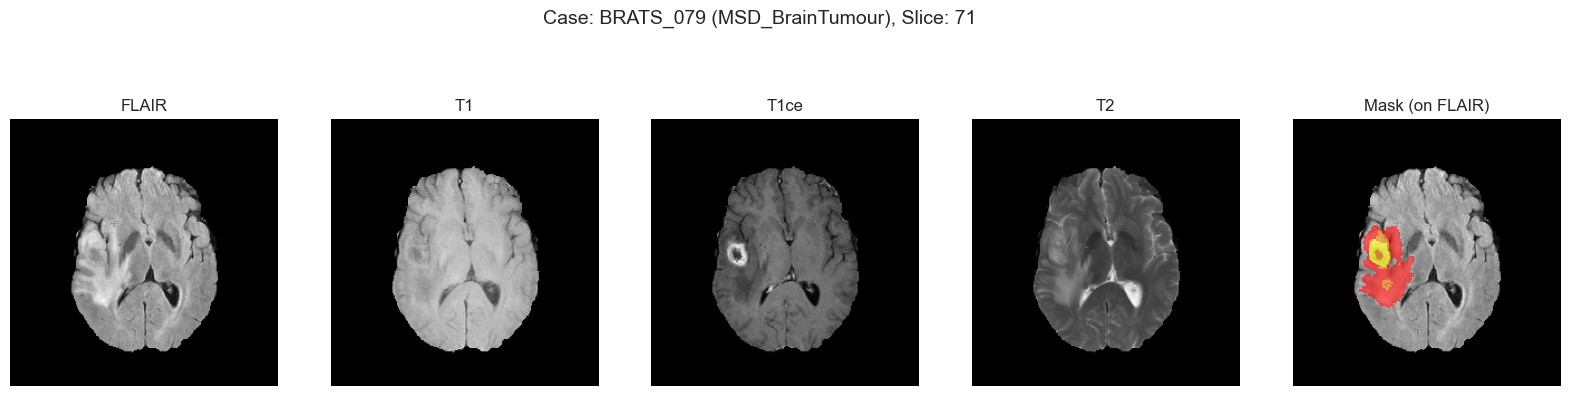

Атипичный случай (малый объем):


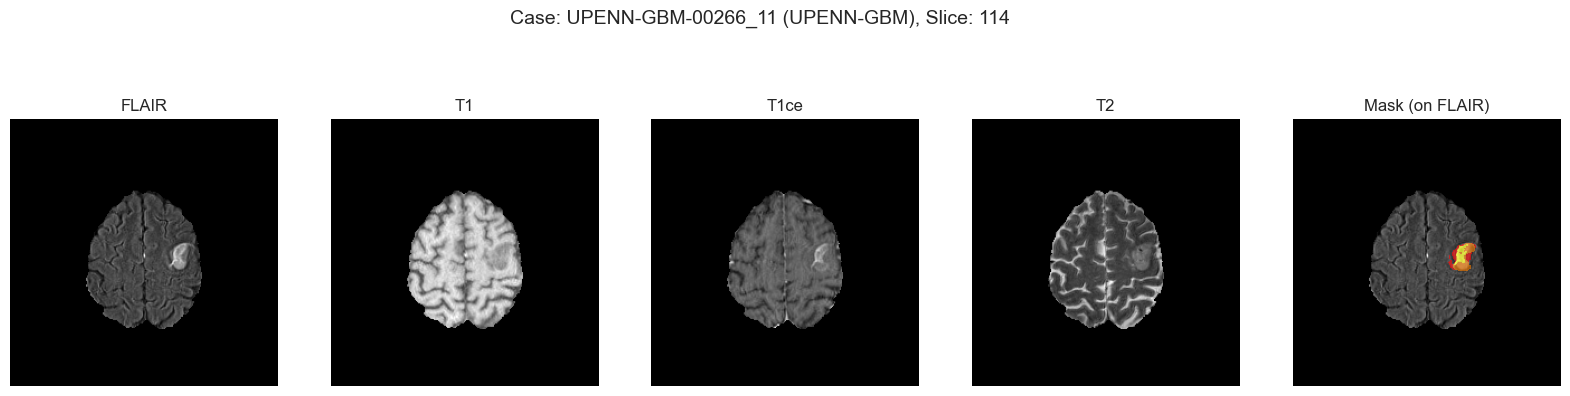

Атипичный случай (большой объем):


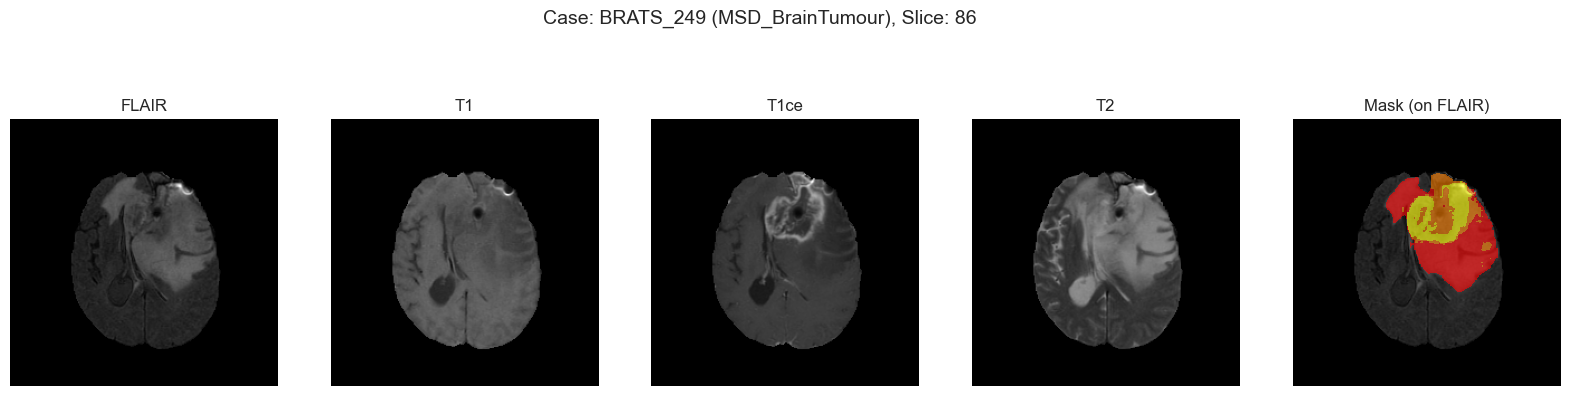

In [40]:
def visualize_case(case_id, dataset):
    path_img = f"../data/processed/{dataset}/imagesTr/{case_id}.nii.gz"
    path_lbl = f"../data/processed/{dataset}/labelsTr/{case_id}.nii.gz"
    if not os.path.exists(path_img):
        path_img = f"data/processed/{dataset}/imagesTr/{case_id}.nii.gz"
        path_lbl = f"data/processed/{dataset}/labelsTr/{case_id}.nii.gz"

    if not os.path.exists(path_img):
        print(f"Error: File not found {path_img}")
        return

    img = nib.load(path_img).get_fdata()
    lbl = nib.load(path_lbl).get_fdata()
    
    # Находим срез с максимальной площадью опухоли
    slice_idx = np.argmax(np.sum(lbl > 0, axis=(0, 1)))
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    modalities = ['FLAIR', 'T1', 'T1ce', 'T2']
    
    for i in range(4):
        axes[i].imshow(img[:, :, slice_idx, i].T, cmap='gray', origin='lower')
        axes[i].set_title(modalities[i])
        axes[i].axis('off')
        
    # Отображаем маску на фоне FLAIR
    axes[4].imshow(img[:, :, slice_idx, 0].T, cmap='gray', origin='lower')
    mask = np.ma.masked_where(lbl[:, :, slice_idx] == 0, lbl[:, :, slice_idx])
    axes[4].imshow(mask.T, cmap='autumn', alpha=0.6, origin='lower', interpolation='none')
    axes[4].set_title('Mask (on FLAIR)')
    axes[4].axis('off')
    
    plt.suptitle(f"Case: {case_id} ({dataset}), Slice: {slice_idx}", fontsize=14)
    plt.show()

# Визуализация примеров
print("Типичный случай (медиана объема):")
visualize_case('BRATS_079', 'MSD_BrainTumour')

print("Атипичный случай (малый объем):")
visualize_case('UPENN-GBM-00266_11', 'UPENN-GBM')

print("Атипичный случай (большой объем):")
visualize_case('BRATS_249', 'MSD_BrainTumour')

Выводы.
- Маски во всех проверенных случаях (включая трансформированный UPENN-GBM) точно соответствуют анатомическим границам опухоли.
- Модальность T1ce критична для ET, а FLAIR — для определения границ отека.
- Малые очаги (менее 10 000 мм³) требуют особого внимания при обучении => Использование Focal Loss, стратегии Foreground Over-sampling и пространственных аугментаций.
- Иногда яркость «плавает» (одна часть мозга чуть темнее другой) => Применение алгоритма Bias Field Correction (N4ITK), чтобы выровнять интенсивность тканей.

## 5. Формирование выборки и стратегия валидации

### Алгоритм формирования выборки:
1. Обучающая и внутренняя тестовая выборка: Используется датасет MSD (484 случая).
2. Внешняя тестовая выборка: Используется датасет UPENN-GBM (147 случаев).

### Стратегия валидации:
- K-Fold Cross-Validation (k=5) на данных MSD. Это обеспечит робастную оценку модели на ограниченном объеме данных.
- Стратификация: При разделении на фолды будет учитываться распределение объемов опухолей (биннинг по объему), чтобы в каждый фолд попали как типичные, так и редкие случаи.
- Final Evaluation: Финальная модель, обученная на всех данных MSD, будет протестирована на UPENN-GBM для оценки обобщающей способности (Domain Generalization).

## 6. Выводы для моделирования

1. **Ресемплирование**: В текущем обработанном наборе (`processed`) все данные приведены к изотропному разрешению 1.0 x 1.0 x 1.0 мм. Однако для работы модели с новыми пациентами "из клиники" необходимо наличие этапа автоматического ресемплирования в пайплайне инференса.
2. **Нормализация**: В МРТ отсутствует абсолютная шкала яркости, поэтому обязательна поканальная нормализация (Z-score) для каждого пациента. Также рекомендуется применение Bias Field Correction (N4ITK) для выравнивания интенсивности внутри снимка.
3. **Размеры входа**: Все снимки имеют пространственный размер 240x240x155. Это позволяет использовать фиксированный размер патча (например, 128x128x128) для обучения модели без риска искажения анатомии.
4. **Стратегия сегментации (Region-based)**: Модель будет обучаться предсказывать три вложенных региона: **WT** (Whole Tumor), **TC** (Tumor Core) и **ET** (Enhancing Tumor). Это обеспечит лучшую сходимость и прямую оптимизацию целевых метрик BraTS.
5. **Баланс классов**: Наблюдается значительный дисбаланс между фоном и опухолью (~1-2% вокселей). Рекомендуется использовать комбинацию **Dice Loss** и **Focal Loss** для стабильного обучения.
6. **Аугментация и кроппинг**: Ввиду того, что большая часть объема 3D-снимка является фоном, при обучении необходимо использовать стратегии **Foreground Over-sampling** (частая выборка патчей, содержащих опухоль) и обрезку неинформативного фона. Для повышения обобщающей способности рекомендуются геометрические аугментации: повороты, масштабирование, зеркальное отображение и эластичные деформации.
7. **Работа с аномалиями**: Наличие случаев без определенных компонентов (например, без ET) диктует необходимость устойчивости модели к отсутствию сигнала в соответствующих каналах маски.
8. **Устранение шума**: Для повышения качества финальной сегментации рекомендуется внедрить постпроцессинг на основе **Connected Component Analysis (CCA)** для удаления мелких изолированных фрагментов (менее 50 вокселей).
9. **Внешняя валидация**: Набор UPENN-GBM после предобработки полностью совместим с MSD, что позволяет использовать его как независимый тестовый набор для проверки обобщающей способности модели.
10. **Визуализация неопределенности**: Внедрение Uncertainty Maps (например, через MC Dropout) критически важно для интерпретации результатов в сомнительных зонах сегментации, что повышает клиническую ценность системы.